In [ ]:
# PySpark Setup - Run this cell first
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install pyspark -q
    !pip install findspark -q
    import findspark
    findspark.init()


## START HIVE
- Step 1:  Start Hadoop Service first
     - Go to the terminal and type `start-all.sh`
     - NOTE:
         - "NameNode listening at - http://localhost:9870/"
         - "ResourceManager Web UI - http://localhost:8088/"
- Step 2: Check if All services are running or not
     - type `jps`. You should see below all.
     - 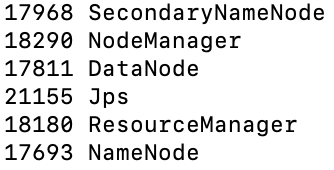
- Step 3: Run below command in terminal.
    - `${HIVE_HOME}/bin/hiveserver2 --hiveconf hive.server2.enable.doAs=false --hiveconf hive.root.logger=DEBUG,console`
    - Running at port 10000
    - username:root
    - password:root-pras-9978
- Step 4: Run below command in another terminal
    - `hive --service metastore`
- Step 5:  Stop Hadoop Service 
     - Go to the terminal and type `stop-all.sh`

## Hive

- SQL layer to communicate with Hadoop Map Reduce
- Created by Facebook
- Hive is not a database 
- Hive is a Query Engine
- Hive is a abstraction of Map Reduce
- By default Hive runs on Map Reduce Engine. Other Engine we can use i.e Tez, Spark.
- In AWS, we have S3.

**NOTE: Spark is a replacement for Map Reduce but not whole Hadoop**

## Hive CLI
- bin/hive
- Hive has a metadata. Metadata contain all the information of the table & Schema but not the data.
- Metadata in Hive is different from metadata in Name node.

Where this Hive Metadata get stored ?
- Hive will store the metadata in RDBMS only.
### Remote Metastore Mechanism.
- Its good practice to install RDBMS such as MySql, etc with installation of Hive.
### Embedded Metastore Mechanism.
- If we don't install any RDBMS, Hive has its own internal RDBMS called Derby to store the metadata of Hive.

- Load Data --- To perform bulk load of data
- Insert -- To insert data one by one.


### Drawback of Embedded Metastore
- Let say we are running a cluster with 4 worker node. Each node has Hive installed. Since Derby(where metadata is stored) is internal RDBMS for Hive, one Derby instance will not be available in other node. So we cannot do a distributed SQL request.
- Therefore, we can have another node where we can have RDBMS installed to store Hive metadata
- These changes can be done in config file of hive.


## Copy file to local to HDFS

`hadoop fs -put data.txt /user/prashant.singh/data.txt`

### Loading Data in Hive
#### From local system:
CREATE TABLE Staff (id int, name string, salary double) row format delimited fields terminated by ',';

LOAD DATA LOCAL INPATH '/home/yourcsvfile.csv' OVERWRITE INTO TABLE Staff;

#### From HDFS:
CREATE TABLE Staff (id int, name string, salary double) row format delimited fields terminated by ',';

LOAD DATA INPATH '/home/yourcsvfile.csv' OVERWRITE INTO TABLE Staff;

### Hive Partitions

### Why??
- To Avoid full scan of the table.
- Query time will get reduce and performance time will increase.
- Two type of partition:
    - Static Partition
    - Dynamic Partition
    
### Static Partition
- While writing query we have to specify, in which partition it should go.

### Dynamic Partition
- We don't have to specify, internally hive will take care of that.

- By default, its a Static partition.

### Create A Non-partition Table

- Step:1
create table user_data_no_partition
(
sno int,
usr_name string,
city string
)
ROW FORMAT delimited fields terminated by ',' LINES TERMINATED BY '\n' STORED AS TEXTFILE;

- Step:2
LOAD DATA INPATH 'datasets/data.txt' INTO TABLE user_data_no_partition;

- Step:3
SELECT * FROM user_data_no_partition;

- we cannot insert data to a partition table using LOAD command
- we can insert data into a partition table from another table

### Static Partition

- Step:1
create table user_data_static_partition
(
sno int,
usr_name string
)partitioned by (city string);

- Step:2
INSERT INTO table user_data_static_partition partition (city='Chennai') SELECT sno,usr_name FROM user_data_no_partition where city='Chennai';

- Step:3
SELECT * FROM user_data_static_partition;

- Hive will store all the table in HDFS under `/user/hive/warehouse/`
- /.hive-staging_hive....... we will see because process is still in progress, once completed it will get removed automatically.
- we need to be very careful while using Static Partition, both the places the condition values get changed. Otherwise wrong values will get append to the partition.

### To know the partitions
SHOW PARTITIONS user_data_static_partition; 

### Dynamic Partition

- By default Dynamic Partition is Disabled, to enable it run below command in Hive Shell.
- In real time mostly people will go for dynamic partition.

`set hive.exec.dynamic.partition.mode=nonstrict`

- Step:1
create table user_data_dynamic_partition(
    sno int,
    usr_name string
)partitioned by (city string);

- Step:2
INSERT INTO table user_data_dynamic_partition partition (city) SELECT sno,usr_name,city FROM user_data_no_partition where city='Chennai';

Or

INSERT INTO table user_data_dynamic_partition partition (city) SELECT sno,usr_name,city FROM user_data_no_partition;

- Step:3
SELECT * FROM user_data_dynamic_partition;

http://localhost:8088/cluster

http://localhost:9870/ 

## Bucket

### Why?
- Data Sampling
- Mapside Join
- Bucket is used to distribute the data

- By default, Hive Shell will not allow us to create the bucket table, to enable it run below commands in Hive Shell.

- Bucket internally decides which data has to go to which bucket, but in partition we have to decide which data has to go to which partition.

- data/row can go to any bucket, we cannot control this. Then how we will know data/row goes to which bucket????

`set hive.exec.dynamic.partition=true`<br>
`set hive.exec.dynamic.partition.mode=nonstrict`<br>
`set hive.enforce.bucketing=true`

### Bucket Internal Mechanism
- Bucket internally uses a algorithm called Hash partition, this will decide which record has to go to which bucket.

#### Hash Partition
- `Formula: hash_of_the_bucketed_column % number_of_buckets`
- Hash Partition will create a Hash value for the bucketed column.
- lets take below as an example to understand. for 3 lets take hash value as 30 and so on...




- In hdfs the bucket will look like 
Index bucket
0     0000-0
1     0001-0
2     0002-0


(amt) % 3
3 (30) --- 30%3=0 --- O denotes the position of the bucket
7
6
15

So above record will go 0th index bucket

### Why we use Bucket if the data is not going according to the values???
- Answer: when we cannot create partition and we want to avoid full scan then we go for bucket.
- we create partition based on values in the column, if the column has unique value then we cannot go by partition then we can got for buckets.

- Step:1
CREATE TEMPORARY TABLE stg_data(
     sno int,
     name string,
     amt int   
) ROW FORMAT delimited fields terminated by ',' LINES TERMINATED BY '\n' STORED AS TEXTFILE;
 
- Step:2
LOAD DATA INPATH 'datasets/data_amt.txt' INTO TABLE stg_data;

- Step:3
CREATE TABLE bk_stg_data(
     sno int,
     name string,
     amt int   
) COMMENT 'A bucketed sorted user table'
CLUSTERED BY (amt) INTO 3 BUCKETS STORED AS TEXTFILE;

- Step:4
INSERT INTO TABLE bk_stg_data SELECT * FROM stg_data;

### Sampling Data
    - Bucket Sampling
    - Block Sampling
    
Below example is of Bucket Sampling

- Step:5
SELECT avg(amt) FROM bk_stg_data TABLESAMPLE(BUCKET 1 OUT OF 3 ON rand()) s;

### To get the information of created table
`show create table bk_stg_data;`

### How to Decide Number of Bucket??
- If we go with random value of bucket, the performance will be still low.
- we have to choose correct bucket count.
- Bucket count depends on the volume of the data.b
- Here is the formula:
    1. Table size = 2300 MB
    2. blocksize = 128MB
    
    2300/128 = 17.96 -- we can take this as a bucket count, but the problem will be if volume of the data increase, using this count will give efficieny issue so again 
                    -- we need to change the bucket count
    
    2^n >= 17.6
    n>=4.1375
    n = 5
    2^5 = 32---this is the bucket count
    
    

### How to update the Bucket Count in the table??
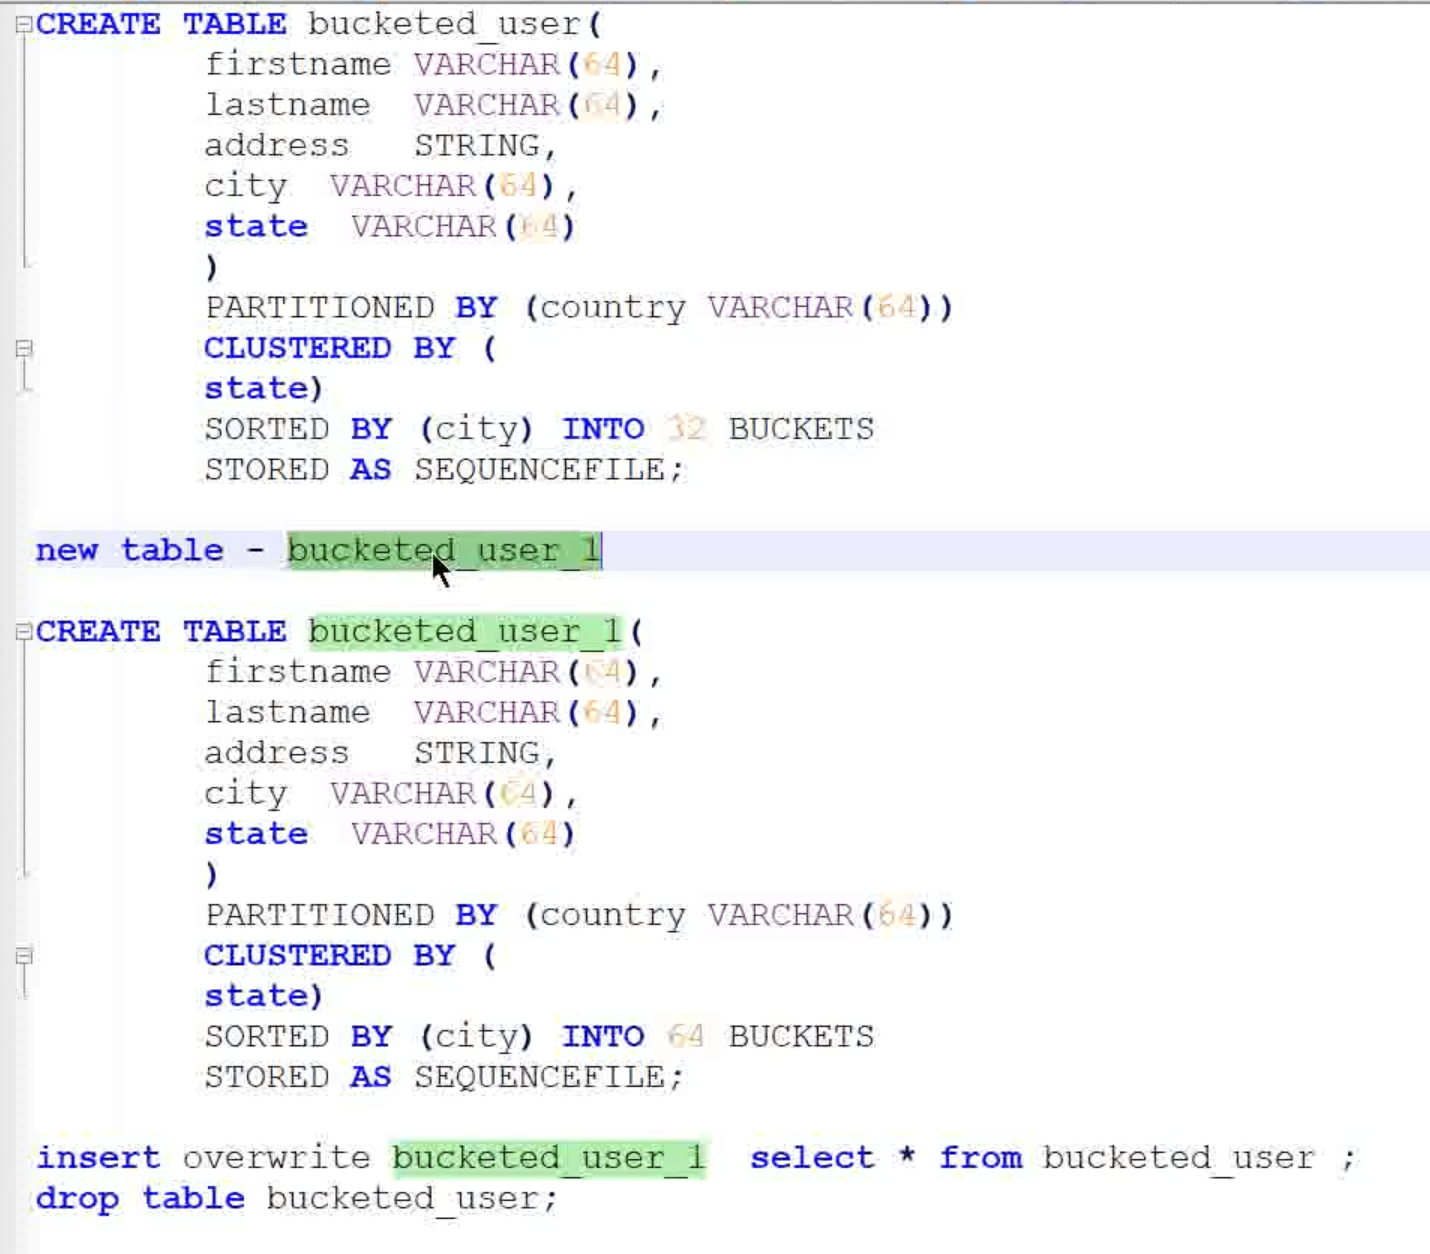

## Partition with Bucket

- we can do one more partition within a partition by columns
- But if its not possible to do sub-partition then will do bucket on top of that.

- Step:1

create table table1(pid INT, pname STRING, drug STRING,gender STRING,tot_amt INT) row format delimited fields terminated by ',' stored as textfile;

- Step:2
load data local inpath '/home/ubuntu/data10.txt' into table table1;

- Step:3
CREATE TABLE partition_bucketed(pid INT, pname STRING, drug STRING, gender 

STRING, tot_amt STRING)

PARTITIONED BY(country STRING)

CLUSTERED BY(pid) 

INTO 4 BUCKETS Row format delimited 

fields terminated by  ','

Stored as textfile;

- Step:4
INSERT OVERWRITE TABLE partition_bucketed PARTITION (country='IND') SELECT * FROM table1;


## Hive File Format

- ORC (Optimised Row Columnar)

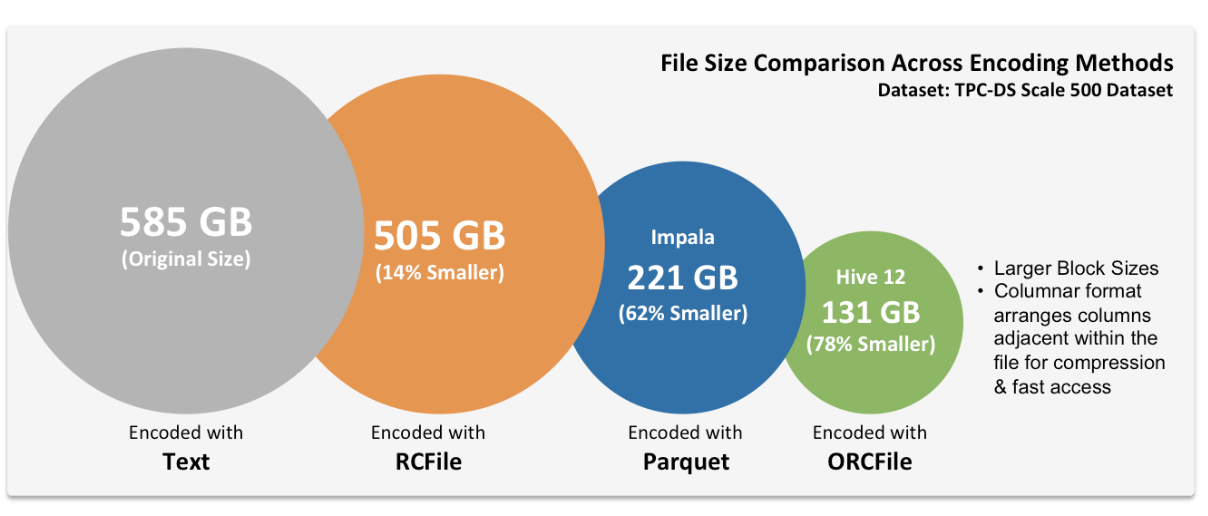

- The data which get stored in ORC will be columnar
- The aggregrate function will be faster for columnar data
- when we create orc table we cannot use LOAD to load the data.
- For loading data into ORC table we need to use INSERT INTO or INSERT OVERWRITE
- File size get compressed with ORC file(upto 75% compression happens in comparision to TEXTFILE)

- If we create Hive Acid table then storage file format should be ORC only.

### Text File Format 

create table table1(pid INT, pname STRING, drug STRING,gender STRING,tot_amt INT) row format delimited fields terminated by ',' stored as textfile;

load data local inpath '/home/ubuntu/<file>.txt' into table table1;

load data local inpath '/home/ubuntu/<file>.txt' into table table1;

show create table table1;

### ORC File Format

create table table2(pid INT, pname STRING, drug STRING,gender STRING,tot_amt INT)row format delimited fields terminated by ',' STORED AS orc ;

insert overwrite table table2 select * from table1;

show create table table2;

Now run the below command and check for the time difference 

select count(*) from table1 where tot_amt =110;

select count(*) from table2 where tot_amt =110;

## AVRO vs Parquet vs ORC
### AVRO
1. Row Oriented Storage
2. Schema stored as JSON within the file itself.
3. Most suitable for write operation.
4. Less efficient in terms of compression
5. These files are mostly used in Kafka based application. 


### Parquet
1. Column Oriented Storage
2. Schema stored in the footer of the file
3. Most suitable for Read operation
4. Works best with Snappy Compression
5. These files are mostly used in Spark based application. 


### ORC
1. Column Oriented Storage
2. Schema stored in the footer of the file
3. Most suitable for Read operation
4. Works best with zlib compression
5. These files are mostly used in Hive based application. 


### Internal vs External table in Hive

### Internal Table